###Bibliotecas iniciais

In [38]:
#Instalações
#!pip install -q kaggle

In [39]:
#Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
import numpy as np
import shap
import kagglehub
from kagglehub import KaggleDatasetAdapter
import os
from google.colab import drive

###Análise câncer de mama


In [40]:
#Importar base do Kaggle e leitura da base transformando-a em um DF
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")
print(path)

os.listdir("/kaggle/input/breast-cancer-wisconsin-data")

df_cancer_mama = pd.read_csv("/kaggle/input/breast-cancer-wisconsin-data/data.csv")
df_cancer_mama.head()

Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.
/kaggle/input/breast-cancer-wisconsin-data


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [41]:
# #Opção de carregamento da base por meio de um arquivo salvo .csv e incluído no sistema
# df_cancer_mama = pd.read_csv ('cancer_mama.csv')


####Análises estatíticas iniciais

In [42]:

# #Retirada de coluna sem dados
df_cancer_mama = df_cancer_mama.drop (columns=['Unnamed: 32'])

#Inclusão coluna numérica para resultado do diagnóstico
df_cancer_mama['result_diagnostico'] = df_cancer_mama['diagnosis'].map({'M': 1, 'B': 0})
df_cancer_mama.head()
df_cancer_mama.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [43]:
# Correlações

# Verificação de dados iniciais
df_cancer_mama.describe(include='all')

#Matriz de correlação geral
corr = df_cancer_mama.corr(numeric_only=True)
corr

#Matriz de correlação focada na variável result_diagnostico
corr['result_diagnostico'].sort_values(ascending=False)

,result_diagnostico
result_diagnostico,1.000000
concave points_worst,0.793566
perimeter_worst,0.782914
concave points_mean,0.776614
radius_worst,0.776454
perimeter_mean,0.742636
area_worst,0.733825
radius_mean,0.730029
area_mean,0.708984
concavity_mean,0.696360


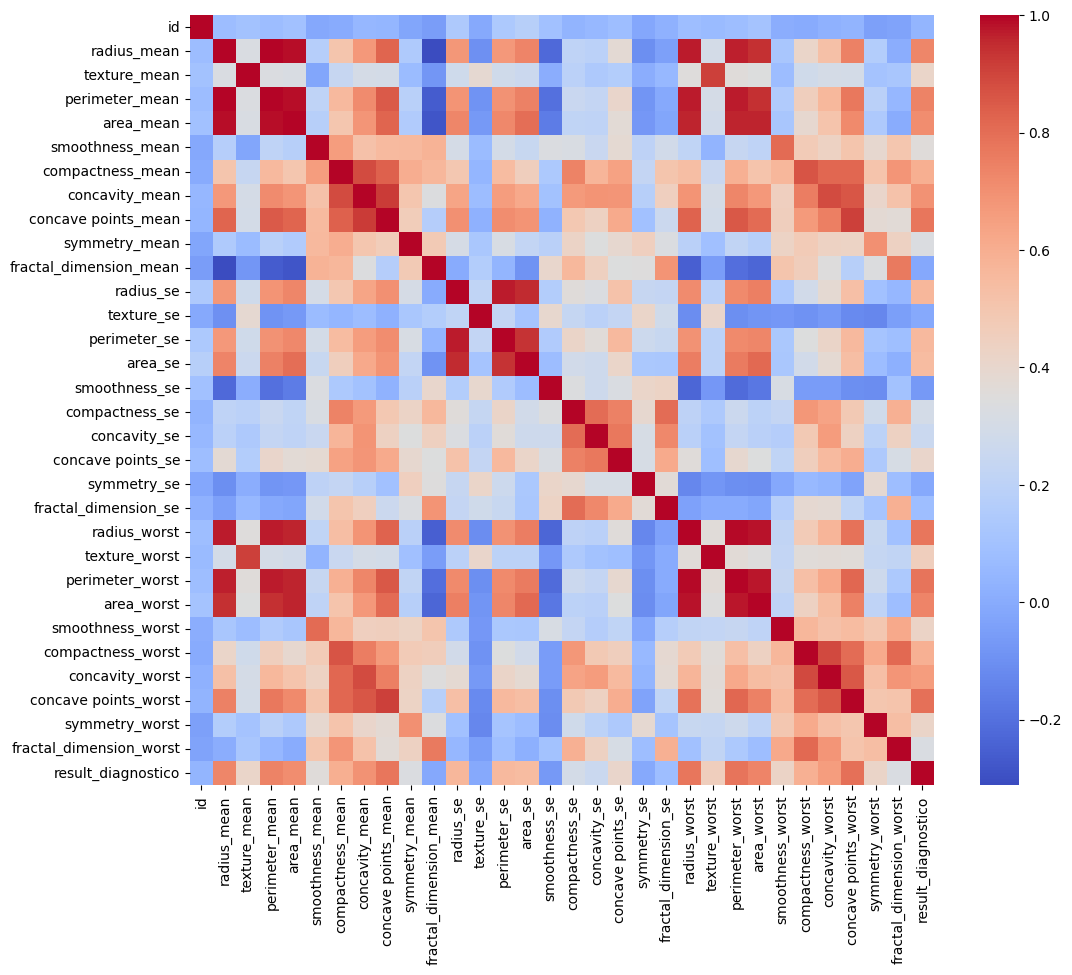

In [44]:
#Heatmap

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.show()

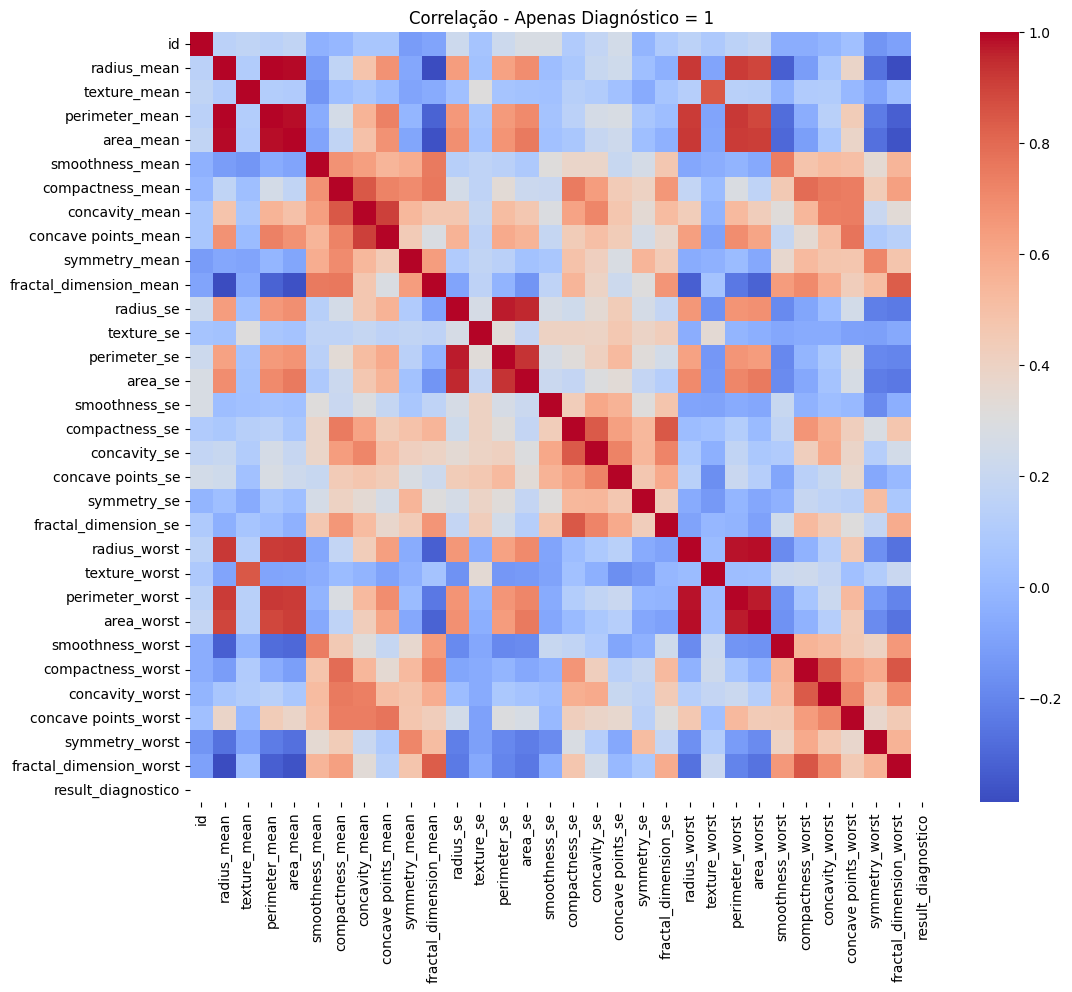

In [45]:
#Análise de Heatmap para os casos que o diagnóstico foi "M" - Maligno para verificar se as variáveis se comportaram da mesma forma
df_cancer_mama_maligno = df_cancer_mama[df_cancer_mama['result_diagnostico'] == 1]
df_cancer_mama_maligno.head ()

#Correlação
corr_m = df_cancer_mama_maligno.corr(numeric_only=True)

#Heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr_m, cmap='coolwarm', annot=False)
plt.title('Correlação - Apenas Diagnóstico = 1')
plt.show()

####Regressão Logística

In [46]:
#Regressão logística escolhida pois os dados estão limpos e tem como base uma variável binária
#Retirada das variáveis que possuem impacto entre -0.1 e 0.1 pois o impacto no result_diagnostico é irrelevante
#Retirada coluna 'diagnosis' pois dados já estão na 'result_diagnosis'
df_cancer_mama_reg = df_cancer_mama.drop(columns= [
                                                  'symmetry_se',
                                                  'texture_se',
                                                  'fractal_dimension_mean',
                                                  'smoothness_se',
                                                  'id',
                                                  'diagnosis']
                                                )
df_cancer_mama_reg.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,radius_se,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,result_diagnostico
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,1.0950,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.5435,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.7456,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.4956,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.7572,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


In [47]:
#Fórmula regressão logística

#Separação treino e teste (proporção 80/20)
X = df_cancer_mama_reg.drop(columns=['result_diagnostico'])
y = df_cancer_mama_reg['result_diagnostico']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,   # 20% teste
    random_state=42, # reprodutibilidade
    stratify=y       # mantém proporção das classes
)

#Treinamento do modelo com inclusão de escalonador pois houve erro por multicolinearidade e aumento do max_iter
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [48]:
#Realização das previsões

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

#Avaliação inicial
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98        72
           1       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

ROC-AUC: 0.996362433862434


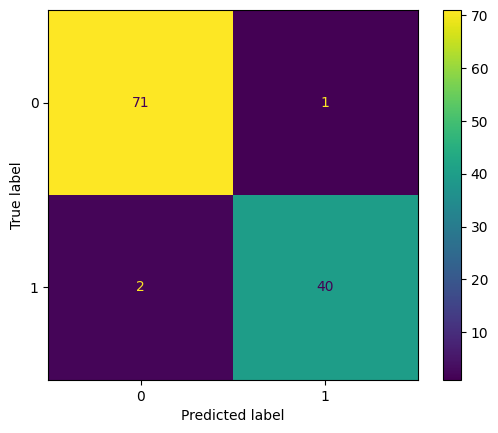

In [49]:
#Matriz de confusão para identificar percentual de falsos positivos e falsos negativos
#Verificar os casos que o câncer era "M", mas foi considerado "B", pois pode levar a falta de tratamento do paciente
y_train_pred = model.predict(X_train)
cm_train = confusion_matrix(y_train, y_train_pred)

y_test_pred = model.predict(X_test)
cm_test = confusion_matrix(y_test, y_test_pred)

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.show()

In [50]:
# Considerações sobre a Regressão Logística
#Para uso comercial o data set é pequeno (apenas 596) casos. Precisaria de uma base de dados maior
#Os resultados são promissores, o risco estão nos falsos negativos que chegam a aproximadamente 5%

####Árvore de decisão

In [51]:
#Retirado somente id e diagnosis, pois a árvore de decisão não é impactada por multicolinearidade
df_cancer_mama_arv = df_cancer_mama.drop(columns= [
                                                  'id',
                                                  'diagnosis']
                                                )
df_cancer_mama_arv.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,result_diagnostico
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


In [52]:
#Separação entre treino e teste (considerando proporção 80/20 e estratificação)
X_arv = df_cancer_mama_arv.drop(columns=['result_diagnostico'])
y_arv = df_cancer_mama_arv['result_diagnostico']

X_arv_train, X_arv_test, y_arv_train, y_arv_test = train_test_split(
    X_arv, y_arv,
    test_size=0.2,     # 20% teste / 80% treino
    random_state=42,
    stratify=y )

In [53]:
# #Conferência da proporcionalidade
# print("Distribuição original:")
# print(y_arv.value_counts(normalize=True))

# print("\nTreino:")
# print(y_arv_train.value_counts(normalize=True))

# print("\nTeste:")
# print(y_arv_test.value_counts(normalize=True))

In [54]:
#Treinamento árvore de decisão
tree = DecisionTreeClassifier(
    max_depth=6,           # controla complexidade
    min_samples_leaf=2,    # evita overfitting
    random_state=42
)

tree.fit(X_arv_train, y_arv_train)


DecisionTreeClassifier(max_depth=6, min_samples_leaf=2, random_state=42)

In [55]:
#Previsões
y_pred_tree = tree.predict(X_arv_test)
y_prob_tree = tree.predict_proba(X_arv_test)[:, 1]

#Resultados
print("\nClassification Report:")
print(classification_report(y_arv_test, y_pred_tree))

print("ROC-AUC:", roc_auc_score(y_arv_test, y_prob_tree))

print("\nMatriz de Confusão:")
print(confusion_matrix(y_arv_test, y_pred_tree))


Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94        72
           1       0.92      0.86      0.89        42

    accuracy                           0.92       114
   macro avg       0.92      0.91      0.91       114
weighted avg       0.92      0.92      0.92       114

ROC-AUC: 0.9173280423280423

Matriz de Confusão:
[[69  3]
 [ 6 36]]


In [56]:
#Resultado pior que o da Regressão logística pois tem mais faltos negativos o que é um problema em se tratando de doenças


####Importance feature

In [57]:
#Regressão Logística
importance_log = pd.DataFrame({
    'feature': X.columns,
    'coef': model.coef_[0],
    'abs_coef': np.abs(model.coef_[0])
}).sort_values(by='abs_coef', ascending=False)

importance_log

,feature,coef,abs_coef
17,texture_worst,1.201261,1.201261
9,radius_se,1.126305,1.126305
16,radius_worst,0.992504,0.992504
24,symmetry_worst,0.972894,0.972894
19,area_worst,0.957376,0.957376
12,compactness_se,-0.905415,0.905415
22,concavity_worst,0.902788,0.902788
7,concave points_mean,0.885902,0.885902
11,area_se,0.866162,0.866162
18,perimeter_worst,0.829521,0.829521


In [58]:
#Árvore de decisão
importance_tree = pd.DataFrame({
    'feature': X_arv.columns,
    'importance': tree.feature_importances_
}).sort_values(by='importance', ascending=False)

importance_tree

,feature,importance
22,perimeter_worst,0.746810
27,concave points_worst,0.069915
1,texture_mean,0.043959
24,smoothness_worst,0.032669
11,texture_se,0.024569
3,area_mean,0.023187
23,area_worst,0.016117
6,concavity_mean,0.011638
21,texture_worst,0.009698
20,radius_worst,0.009698


Análise combinada dos dois modelos:
- variáveis em comum: perimeter_worst / concave points_worst / texture_mean / texture_worst / area_worst / radius_worst
- Regressão Linear considera mais variáveis
- Árvore de decisão se concentra em poucas variáveis (o que pode explicar o falso negativo)

####Sharp

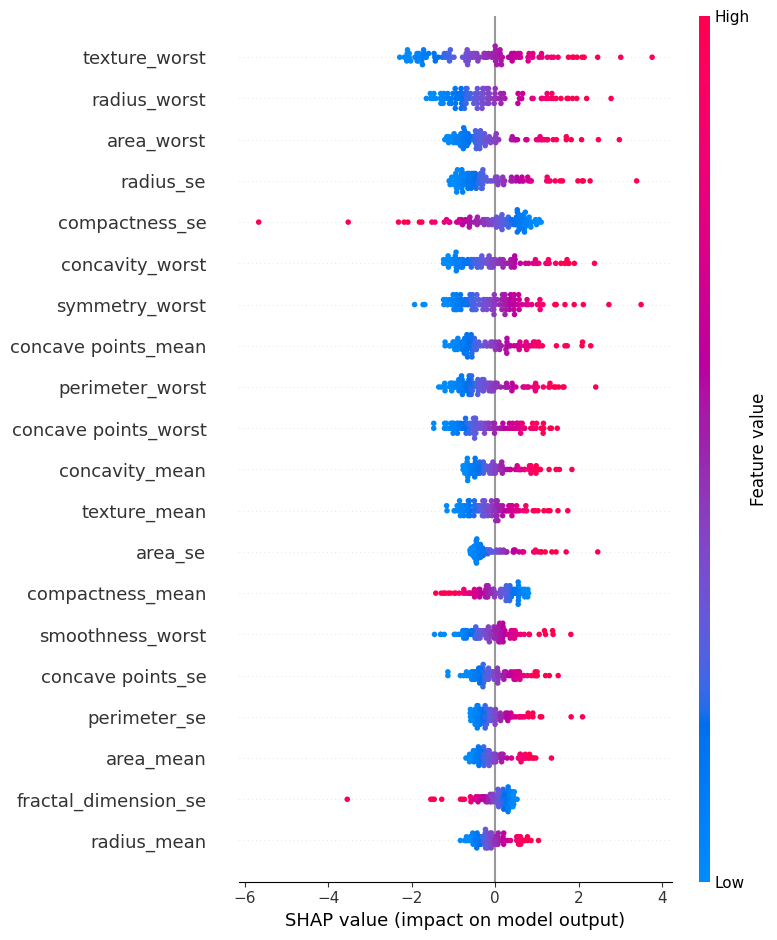

In [59]:
#Regressão logística


#Recriar nome das colunas em razão do uso do Scaler na Regressão Logística
X_train_df = pd.DataFrame(X_train, columns=X.columns)
X_test_df  = pd.DataFrame(X_test,  columns=X.columns)


explainer = shap.Explainer(model, X_train_df)
shap_values = explainer(X_test_df)

shap.summary_plot(shap_values, X_test_df)

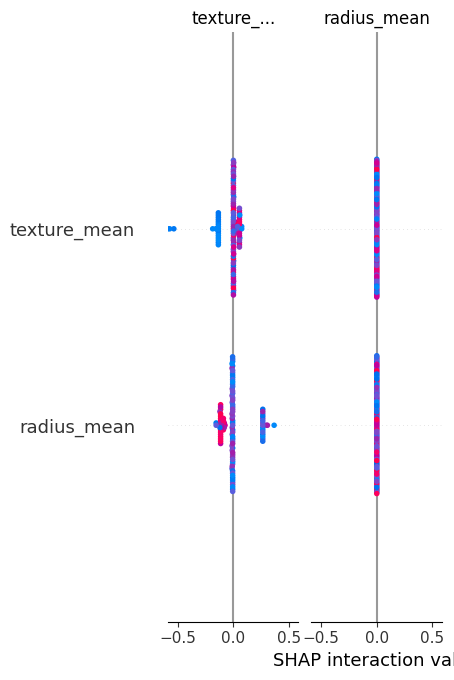

In [60]:
#Árvore de decisão
X_arv_train_df = pd.DataFrame(X_arv_train, columns=X_arv.columns)
X_arv_test_df  = pd.DataFrame(X_arv_test,  columns=X_arv.columns)

explainer_tree = shap.Explainer(tree, X_arv_train_df)
shap_values_tree = explainer_tree(X_arv_test_df)

shap.summary_plot(shap_values_tree, X_arv_test_df)

Conclusão do Sharp
- A regressão utiliza mais fontes para a análise e se destacam o itens que representam aumento de risco para câncer maligno: texture_worst alto / radius_worst alto
- A regressão está sendo um modelo equilibrado, estável e bem distribuído
- A árvore de decisão se concentra em poucas variáveis com a maioria estando zerada, o que também foi oservado em outras análises

###Opção de Regressão Logística após utilização de PCA para tratar as correlações

In [61]:
#Escolha da quantidade de componentes para o teste

# Separar variáveis preditoras
X_pca = df_cancer_mama.drop(columns=['diagnosis','id'])

# Padronizar dados
scaler = StandardScaler()
X_pca_scaled = scaler.fit_transform(X_pca)

# Loop testando quantidade de componentes
resultados_pca = []

for n in range(1, X.shape[1] + 1):

    pca = PCA(n_components=n)
    X_pca_final = pca.fit_transform(X_pca_scaled)

    variancia = pca.explained_variance_ratio_.sum()

    resultados_pca.append([n, variancia])

# Resultado em DataFrame
resultado_pca_df = pd.DataFrame(
    resultados_pca,
    columns=['componentes', 'variancia_acumulada']
)

resultado_pca_df

,componentes,variancia_acumulada
0,1,0.448960
1,2,0.633681
2,3,0.725515
3,4,0.789979
4,5,0.843497
5,6,0.882449
6,7,0.904537
7,8,0.920177
8,9,0.933626
9,10,0.944945


In [62]:
print('Escolhida a opção com 10 componentes pois representa 95% dos dados, valor significa e que "exclui" os itens com pouco peso na análise')

Escolhida a opção com 10 componentes pois representa 95% dos dados, valor significa e que "exclui" os itens com pouco peso na análise


In [63]:
# Variáveis com nomes específicos para não confundir com as células anteriores
X_reg_pca = df_cancer_mama.drop(columns=['diagnosis','id'])
y_reg_pca = df_cancer_mama['result_diagnostico']

# Treino e teste com 20%
X_reg_pca_train, X_reg_pca_test, y_reg_pca_train, y_reg_pca_test = train_test_split(
    X_reg_pca, y_reg_pca, test_size=0.2, random_state=42, stratify=y_reg_pca
)

# Padronização
scaler = StandardScaler()
X_reg_pca_train_scaled = scaler.fit_transform(X_reg_pca_train)
X_reg_pca_test_scaled = scaler.transform(X_reg_pca_test)

# PCA com 10 componentes
pca = PCA(n_components=10)
X_train_pca = pca.fit_transform(X_reg_pca_train_scaled)
X_test_pca = pca.transform(X_reg_pca_test_scaled)

# Regressão Logística
modelo = LogisticRegression(max_iter=5000)
modelo.fit(X_train_pca, y_reg_pca_train)

# Previsões
y_reg_pca_pred = modelo.predict(X_test_pca)

# Resultados
print("Accuracy:", accuracy_score(y_reg_pca_test, y_reg_pca_pred))
print(confusion_matrix(y_reg_pca_test, y_reg_pca_pred))
print(classification_report(y_reg_pca_test, y_reg_pca_pred))

Accuracy: 0.9912280701754386
[[72  0]
 [ 1 41]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        72
           1       1.00      0.98      0.99        42

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



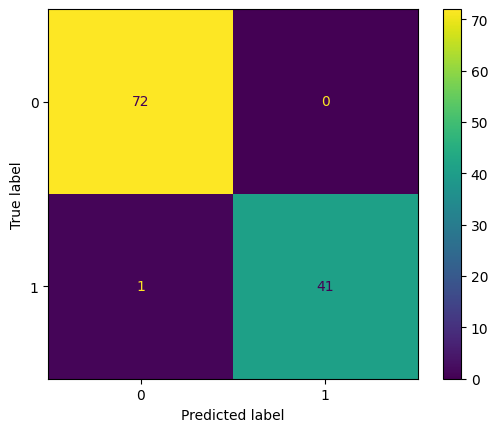

In [64]:
# Previsões treino
y_reg_pca_train_pred = modelo.predict(X_train_pca)
cm_train = confusion_matrix(y_reg_pca_train, y_reg_pca_train_pred)

# Previsões teste
y_reg_pca_test_pred = modelo.predict(X_test_pca)
cm_test = confusion_matrix(y_reg_pca_test, y_reg_pca_test_pred)

# Exibir matriz de confusão teste
ConfusionMatrixDisplay.from_predictions(
    y_reg_pca_test,
    y_reg_pca_test_pred
)

plt.show()

In [65]:
#Comparação das Matrizes de Confusão das duas regressões

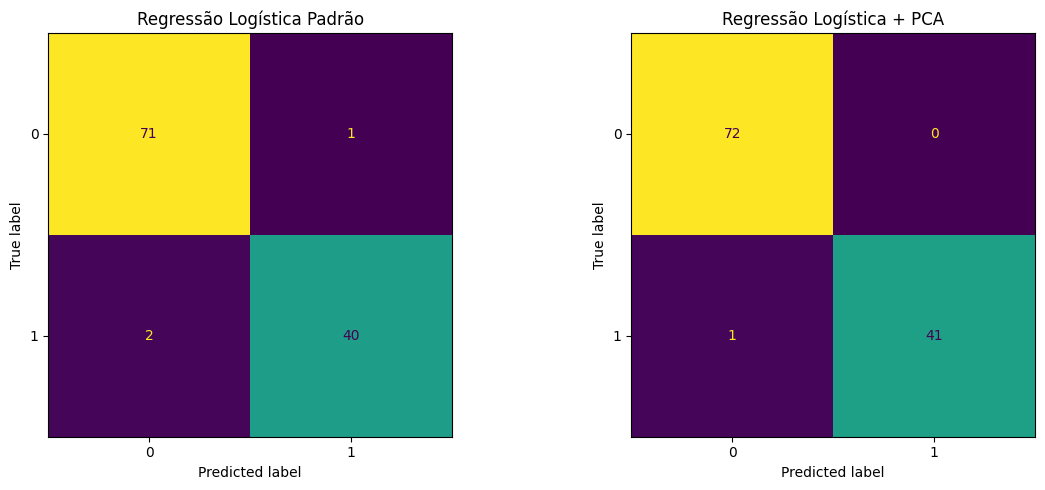

In [68]:

# Regressão logística padrão
y_pred_log = model.predict(X_test)

# Regressão logística com PCA
y_pred_pca = modelo.predict(X_test_pca)

# Matrizes de confusão
cm_log = confusion_matrix(y_test, y_pred_log)
cm_pca = confusion_matrix(y_reg_pca_test, y_pred_pca)

# Comparação visual
fig, ax = plt.subplots(1, 2, figsize=(12,5))

ConfusionMatrixDisplay(cm_log).plot(ax=ax[0], colorbar=False)
ax[0].set_title("Regressão Logística Padrão")

ConfusionMatrixDisplay(cm_pca).plot(ax=ax[1], colorbar=False)
ax[1].set_title("Regressão Logística + PCA")

plt.tight_layout()
plt.show()

A aplicação de PCA antes da regressão logística melhorou o desempenho preditivo do modelo, aumentando a taxa de acerto e reduzindo erros críticos (falsos negativos). Isso indica que a redução de dimensionalidade contribuiu para maior robustez e capacidade de generalização.
Mas continua se tratando de uma base de dados pequena para o perfil e importância da atuação. Neste caso, para um uso efetivo seria necessário ffazer mais testes e com base mais extensa para uma opção de uso real da ferramenta
